# AICE Associate DAY 17-1 — 회귀 종합 실전

이번 세트는 **회귀(Regression)** 중심입니다.  
최근 분류를 많이 연습했으므로, 오늘은 머신러닝 + 딥러닝 모두 **배송 소요시간(`delivery_time_min`) 예측**으로 구성했습니다.

### 포함한 복습 포인트
- 조건에 맞는 **행 삭제/필터링**
- `isin()`으로 여러 범주 한 번에 처리
- 축 눈금 회전
- `get_dummies()`
- **train에는 `fit_transform`, valid에는 `transform`**
- `RobustScaler`
- `mean_absolute_error`
- RandomForest 변수 중요도
- 딥러닝 회귀 출력층: **Dense(1, activation='linear')**
- `Input(shape=(X_train_scaled.shape[1],))`
- EarlyStopping
- `history.history` 그래프

> CSV 파일은 이 노트북과 같은 폴더에 두고 실행하세요.


## 데이터 컬럼 설명

| 컬럼 | 의미 |
|---|---|
| order_id | 주문 ID |
| order_date | 주문 날짜 |
| distance_km | 배송 거리(km) |
| traffic_index | 교통 혼잡 지수 |
| stop_count | 경유지 수 |
| driver_experience_years | 기사 경력(년) |
| region | 배송 지역 |
| weather | 날씨 |
| vehicle_type | 배송 수단 |
| service_level | 서비스 등급 |
| package_type | 화물 종류 |
| delivery_fee | 배송비 |
| departure_hour | 출발 시각(0~23) |
| delivery_time_min | **예측 대상: 배송 소요시간(분)** |


## 1. 라이브러리와 데이터 불러오기

1. pandas는 `pd`, numpy는 `np`, seaborn은 `sns`, matplotlib.pyplot은 `plt` 별칭으로 불러오세요.
2. `day17-1_delivery_data.csv`를 읽어 `data`에 저장하세요.
3. 첫 4개 행을 출력하세요.

> 파일은 UTF-8 BOM으로 저장되어 있습니다. 일반적인 `pd.read_csv()`로 읽으면 됩니다.


In [1]:
# 여기에 답안코드를 작성하고 실행하세요
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('day17-1_delivery_data.csv')

data.head()

,order_id,order_date,distance_km,traffic_index,stop_count,driver_experience_years,region,weather,vehicle_type,service_level,package_type,delivery_fee,departure_hour,delivery_time_min
0,ORD-20260000,2026-06-13,24.48,32.3,5,4.1,Daegu,clear,motorbike,express,small,7013.0,20,107.2
1,ORD-20260001,2026-04-18,29.98,74.7,6,0.2,Busan,snow,truck,normal,large,5892.0,6,174.3
2,ORD-20260002,2026-06-30,20.97,62.9,3,5.5,Seoul,clear,truck,normal,small|fragile,4508.0,10,124.4
3,ORD-20260003,2026-01-01,10.81,58.6,2,3.9,Seoul,clear,truck,express,medium,5604.0,11,76.9
4,ORD-20260004,2026-08-06,10.57,34.9,7,2.7,Busan,clear,truck,normal,small,3828.0,9,101.0


## 2. 기본 탐색

다음을 한 번에 확인하세요.

- 데이터 크기
- 각 컬럼의 자료형
- 결측치 개수
- 수치형 컬럼의 기술통계량


In [2]:
# 여기에 답안코드를 작성하고 실행하세요
data.shape
data.dtypes
data.isnull().sum()
data.describe()

,distance_km,traffic_index,stop_count,driver_experience_years,delivery_fee,departure_hour,delivery_time_min
count,1400.000000,1400.000000,1400.000000,1376.000000,1380.000000,1400.000000,1400.000000
mean,23.477014,55.588643,4.991429,4.238953,5915.532609,13.827857,118.666429
std,19.189569,19.356546,2.260374,2.223843,1559.851749,4.950615,31.899533
min,2.810000,5.000000,0.000000,0.200000,2189.000000,6.000000,42.800000
25%,13.237500,43.375000,3.000000,2.600000,4760.500000,10.000000,95.900000
50%,20.010000,55.100000,5.000000,4.200000,5773.500000,14.000000,114.700000
75%,29.467500,67.100000,6.000000,5.700000,6838.250000,18.000000,136.250000
max,253.160000,197.300000,14.000000,12.000000,12376.000000,22.000000,257.700000


## 3. 시각화 — 최근 헷갈렸던 축 눈금 회전 포함

가로 방향으로 2개의 그래프를 나란히 그리세요.

- 왼쪽: `region`의 countplot, 제목은 `Region Count`
- 오른쪽: `delivery_time_min`의 histplot, `hue='service_level'`, 제목은 `Delivery Time`
- 왼쪽 그래프의 X축 눈금을 **45도 회전**
- `figsize=(14, 5)`

`plt.subplots()`를 사용하세요.


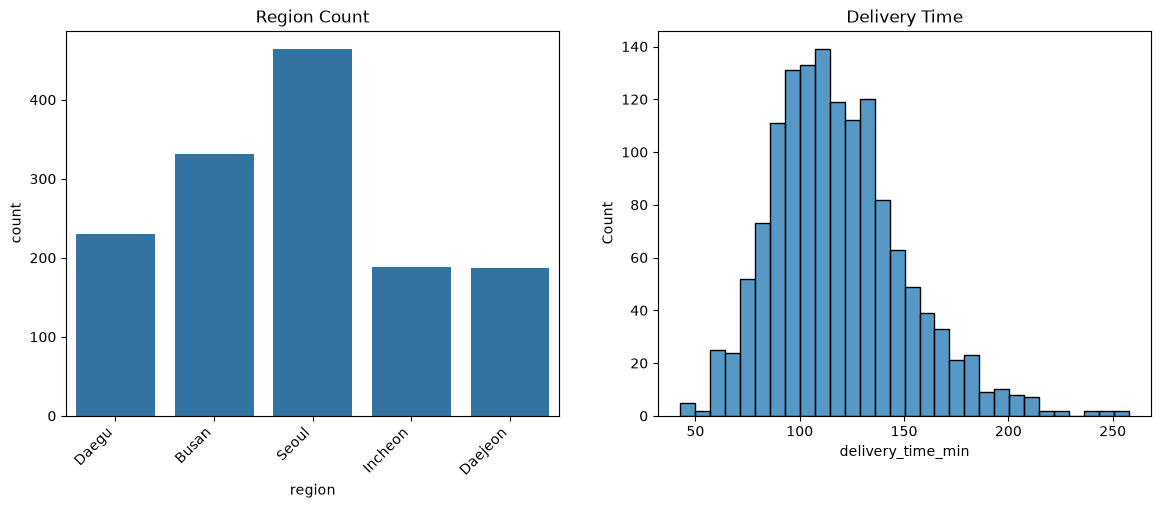

In [3]:
# 여기에 답안코드를 작성하고 실행하세요
fig, axes = plt.subplots(
  nrows=1,
  ncols=2,
  figsize=(14, 5)
)

sns.countplot(data=data, x='region', ax=axes[0])
sns.histplot(data=data, x='delivery_time_min', ax=axes[1])

# 눈금 회전
plt.setp(
  axes[0].get_xticklabels(),
  rotation=45,
  ha='right'
)

axes[0].set_title('Region Count')
axes[1].set_title('Delivery Time')

plt.show()

## 4. 이상치 확인 및 행 삭제

`distance_km`의 분포를 boxplot으로 확인한 뒤 다음 조건을 만족하도록 처리하세요.

- `distance_km >= 150` 인 행 삭제
- `traffic_index > 120` 인 행 삭제
- 모델링에 불필요한 `order_id` 삭제
- 결과를 `data_temp`에 저장
- 처리 전/후 행 개수를 출력

> 주의: `df.drop(df['컬럼'] >= 값)`처럼 **boolean 조건 자체를 drop에 넣는 방식은 사용하지 않습니다.**


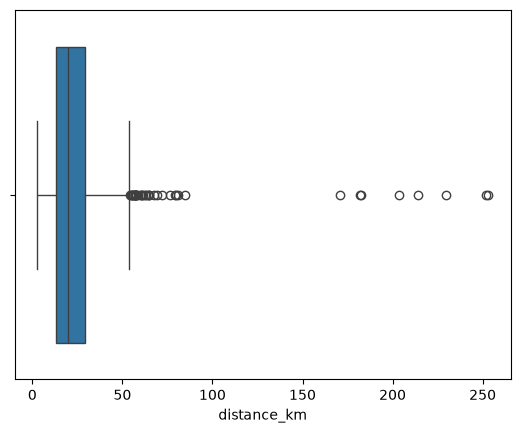

In [4]:
# 여기에 답안코드를 작성하고 실행하세요
sns.boxplot(data=data, x='distance_km')
plt.show()

In [5]:
data_clear = data.copy()
data = data[data['distance_km'] < 150]
data = data[data['traffic_index'] <= 120]

In [6]:
data = data.drop(columns=['order_id'])
data_temp = data.copy()

data_temp.shape

(1386, 13)

## 5. 결측치 처리

`data_temp`의 결측치를 확인하세요.

- `driver_experience_years` → 중앙값으로 채우기
- `delivery_fee` → 평균값으로 채우기
- 처리 결과를 `data_na`에 저장
- 결측치가 모두 사라졌는지 검증


In [7]:
# 여기에 답안코드를 작성하고 실행하세요
data_temp.isnull().sum()

data_temp['driver_experience_years'] = data_temp['driver_experience_years'].fillna(data_temp['driver_experience_years'].median())
data_temp['delivery_fee'] = data_temp['delivery_fee'].fillna(data_temp['delivery_fee'].mean())
data_na = data_temp.copy()

data_na.isnull().sum()

order_date                 0
distance_km                0
traffic_index              0
stop_count                 0
driver_experience_years    0
region                     0
weather                    0
vehicle_type               0
service_level              0
package_type               0
delivery_fee               0
departure_hour             0
delivery_time_min          0
dtype: int64

## 6. `isin()` 복습 — 여러 범주를 한 번에 묶기

`package_type`에 아래 값들이 들어 있습니다.

- `small|fragile`
- `medium|fragile`
- `large|fragile`

위 3개 값에 해당하면 모두 `'fragile'`로 바꾸세요.

그 외 `small`, `medium`, `large` 값은 그대로 둡니다.

- 대상 데이터프레임: `data_na`
- 처리 후 `package_type`의 `value_counts()` 출력

> 여러 값 중 하나인지 확인할 때 `isin([...])`을 사용합니다.


In [8]:
# 여기에 답안코드를 작성하고 실행하세요
# 앞에 컬럼 적지말것
data_na.loc[data_na['package_type'].isin(['small|fragile', 'medium|fragile', 'large|fragile']), 'package_type'] = 'fragile'

In [9]:
data_na['package_type'].value_counts()

package_type
fragile    460
medium     409
small      318
large      199
Name: count, dtype: int64

## 7. 날짜 파생변수 만들기

`order_date`를 datetime으로 변환한 뒤 아래 파생변수를 만드세요.

- `order_month`
- `order_dayofweek`
- `is_weekend` : 토/일이면 1, 아니면 0

마지막에는 원본 `order_date` 컬럼을 삭제하세요.

결과는 계속 `data_na`에 반영합니다.


In [10]:
# 여기에 답안코드를 작성하고 실행하세요
data_na['order_date'] = pd.to_datetime(data_na['order_date'])

data_na['order_month'] = data_na['order_date'].dt.month
data_na['order_dayofweek'] = data_na['order_date'].dt.dayofweek
# 기억하기
data_na['is_weekend'] = (data_na['order_dayofweek'].isin([5,6])).astype(int)

data_na = data_na.drop(columns=['order_date'])

In [12]:
data_na.head()

,distance_km,traffic_index,stop_count,driver_experience_years,region,weather,vehicle_type,service_level,package_type,delivery_fee,departure_hour,delivery_time_min,order_month,order_dayofweek,is_weekend
0,24.48,32.3,5,4.1,Daegu,clear,motorbike,express,small,7013.0,20,107.2,6,5,1
1,29.98,74.7,6,0.2,Busan,snow,truck,normal,large,5892.0,6,174.3,4,5,1
2,20.97,62.9,3,5.5,Seoul,clear,truck,normal,fragile,4508.0,10,124.4,6,1,0
3,10.81,58.6,2,3.9,Seoul,clear,truck,express,medium,5604.0,11,76.9,1,3,0
4,10.57,34.9,7,2.7,Busan,clear,truck,normal,small,3828.0,9,101.0,8,3,0


## 8. 원-핫 인코딩

다음 범주형 컬럼을 `pd.get_dummies()`로 원-핫 인코딩하세요.

- `region`
- `weather`
- `vehicle_type`
- `service_level`
- `package_type`

조건:
- `drop_first=True`
- 결과는 `data_preset`에 저장
- `data_preset.info()`로 확인


In [11]:
# 여기에 답안코드를 작성하고 실행하세요
data_preset = pd.get_dummies(data_na, columns=['region', 'weather', 'vehicle_type', 'service_level', 'package_type'], drop_first=True)

In [12]:
data_preset.info()

<class 'pandas.DataFrame'>
Index: 1386 entries, 0 to 1399
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   distance_km              1386 non-null   float64
 1   traffic_index            1386 non-null   float64
 2   stop_count               1386 non-null   int64  
 3   driver_experience_years  1386 non-null   float64
 4   delivery_fee             1386 non-null   float64
 5   departure_hour           1386 non-null   int64  
 6   delivery_time_min        1386 non-null   float64
 7   order_month              1386 non-null   int32  
 8   order_dayofweek          1386 non-null   int32  
 9   is_weekend               1386 non-null   int64  
 10  region_Daegu             1386 non-null   bool   
 11  region_Daejeon           1386 non-null   bool   
 12  region_Incheon           1386 non-null   bool   
 13  region_Seoul             1386 non-null   bool   
 14  weather_cloudy           1386 non-null  

## 9. X / y 분리와 train / valid 분리

예측 대상은 `delivery_time_min`입니다.

- `X`: 나머지 피처
- `y`: `delivery_time_min`
- train : valid = 80 : 20
- `random_state=17`
- 변수명은 `X_train`, `X_valid`, `y_train`, `y_valid`

> 회귀이므로 `stratify=y`는 사용하지 않습니다.


In [13]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.model_selection import train_test_split

X = data_preset.drop(columns=['delivery_time_min'])
y = data_preset['delivery_time_min']

X_train, X_valid, y_train, y_valid = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=17
)

## 10. RobustScaler — 오류 수정 문제

아래 코드는 잘못되어 있습니다. 오류를 수정하세요.

조건:
- `RobustScaler`를 `rs`에 저장
- **훈련 데이터에만 기준을 학습**
- 검증 데이터에는 훈련 데이터에서 학습한 기준만 적용
- 결과 변수명: `X_train_scaled`, `X_valid_scaled`


In [15]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()

# 아래 두 줄의 오류를 수정하세요.
X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.transform(X_valid)


## 11. 머신러닝 회귀 모델 비교

아래 두 모델을 학습하세요.

### LinearRegression
- 변수명: `lr`

### RandomForestRegressor
- 변수명: `rf`
- `n_estimators=200`
- `max_depth=10`
- `min_samples_split=3`
- `random_state=17`
- `n_jobs=-1`

두 모델 모두 **스케일링된 훈련 데이터**로 학습하세요.


In [16]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lf = LinearRegression()

rf = RandomForestRegressor(
  n_estimators=200,
  max_depth=10,
  min_samples_split=3,
  random_state=17,
  # 머임
  n_jobs=1
)

lf.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train);

## 12. 회귀 평가 — MAE / RMSE / R²

검증 데이터로 두 모델을 평가하세요.

각 모델에 대해 다음 값을 구하세요.

- MAE
- RMSE
- R²

조건:
- `mean_absolute_error`
- `mean_squared_error`
- `r2_score`
- RMSE는 MSE에 제곱근을 적용해서 계산
- 결과를 보기 좋게 출력

> 예전에 헷갈렸던 `mean.absolute` 같은 함수는 없습니다. 함수 이름은 `mean_absolute_error()`입니다.


In [17]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_lf = lf.predict(X_valid_scaled)
pred_rf = rf.predict(X_valid_scaled)

mae_lf = mean_absolute_error(y_valid, pred_lf)
mae_rf = mean_absolute_error(y_valid, pred_rf)

mse_lf = mean_squared_error(y_valid, pred_lf)
mse_rf = mean_squared_error(y_valid, pred_rf)

rmse_lf = np.sqrt(mse_lf)
rmse_rf = np.sqrt(mse_rf)

r2_lf = r2_score(y_valid, pred_lf)
r2_rf = r2_score(y_valid, pred_rf)

print("lf : mae =", mae_lf, ", rmse =", rmse_lf,", r2 =", r2_lf)
print("rf : mae =", mae_rf, ", rmse =", rmse_rf,", r2 =", r2_rf)

lf : mae = 6.29118529397532 , rmse = 7.741773408881329 , r2 = 0.9384152646066416
rf : mae = 8.801619783257612 , rmse = 10.880772978828087 , r2 = 0.8783501252814763


## 13. RandomForest 변수 중요도

`rf.feature_importances_`와 `X.columns`를 이용해 변수 중요도 데이터프레임을 만드세요.

- 컬럼명: `feature`, `importance`
- 중요도 내림차순
- 상위 10개
- seaborn `barplot`
- X축: importance
- Y축: feature


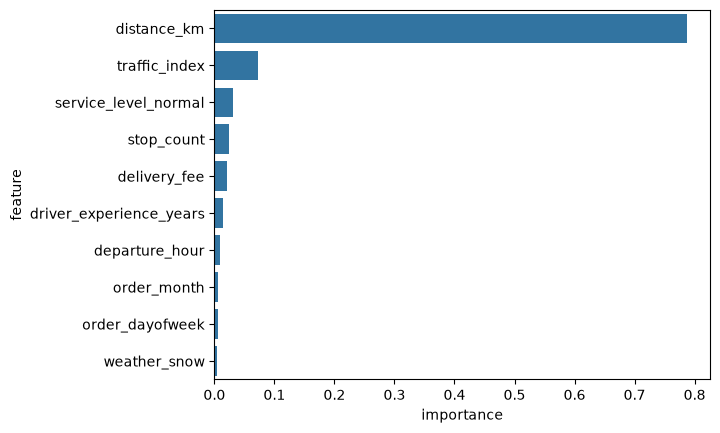

In [20]:
# 여기에 답안코드를 작성하고 실행하세요
fi = pd.DataFrame({
  'feature':X.columns,
  'importance':rf.feature_importances_
})

fi = fi.sort_values(by='importance', ascending=False).head(10)

sns.barplot(data=fi, x='importance', y='feature')
plt.show()

## 14. 딥러닝 회귀 모델 만들기

TensorFlow/Keras로 아래 구조의 회귀 모델을 만드세요.

- `Input(shape=(X_train_scaled.shape[1],))`
- Dense(64, activation='relu')
- Dropout(0.2)
- Dense(32, activation='relu')
- Dense(16, activation='relu')
- **Dense(1, activation='linear')**

컴파일:
- optimizer = `'adam'`
- loss = `'mean_squared_error'`
- metrics = `['mae']`

> 여기서 `X_train_scaled[1]`이 아니라 **`X_train_scaled.shape[1]`** 입니다. 행 하나를 가져오는 것과, 피처 개수를 가져오는 건 우주적으로 다른 일입니다.


In [25]:
# 여기에 답안코드를 작성하고 실행하세요
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer = 'adam',
    loss ='mean_squared_error',
    metrics=['mae']
)

## 15. EarlyStopping + 학습

EarlyStopping을 아래 조건으로 설정하세요.

- `monitor='val_loss'`
- `patience=8`
- `restore_best_weights=True`

학습 조건:
- `epochs=80`
- `batch_size=64`
- `validation_data=(X_valid_scaled, y_valid)`
- `callbacks=[estop]`
- 학습 결과는 `history`에 저장


In [26]:
# 여기에 답안코드를 작성하고 실행하세요
from tensorflow.keras.callbacks import EarlyStopping

estop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=64,
    validation_data=(X_valid_scaled, y_valid),
    callbacks=[estop]
)

Epoch 1/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 14885.9297 - mae: 117.7392 - val_loss: 14716.3486 - val_mae: 117.2513
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14417.2861 - mae: 115.7606 - val_loss: 14013.6650 - val_mae: 114.2698
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13365.9746 - mae: 111.1737 - val_loss: 12431.2412 - val_mae: 107.2408
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11117.7559 - mae: 100.6502 - val_loss: 9362.7617 - val_mae: 91.9907
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7339.5903 - mae: 79.6483 - val_loss: 5003.7866 - val_mae: 63.8218
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3224.1216 - mae: 48.1696 - val_loss: 1872.4139 - val_mae: 35.7697
Epoch 7/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1550.8563 - mae: 31.9594 - val_loss: 1364.5295 - val_mae: 29.9643
Epoch 8/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1317.0128 - mae: 29.6496 - val_loss: 1102.0392 - val_mae: 2

## 16. 딥러닝 평가

학습된 딥러닝 모델로 `X_valid_scaled`를 예측하세요.

- 예측값 변수명: `y_pred_dl`
- MAE
- RMSE
- R²

를 계산해서 출력하세요.

> Keras의 예측 결과가 `(행 개수, 1)` 형태라면 필요할 경우 1차원으로 변환하세요.


In [37]:
# 여기에 답안코드를 작성하고 실행하세요
y_pred_dl = model.predict(X_valid_scaled)

mae = mean_absolute_error(y_valid, y_pred_dl)
mse = mean_squared_error(y_valid, y_pred_dl)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred_dl)

print(mae, rmse, r2)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7.372045264484212 9.203485890886338 0.9129644116227368


## 17. 학습 그래프

`history.history`를 이용해 하나의 그래프에 아래 두 값을 그리세요.

- `mae`
- `val_mae`

조건:
- 제목: `Model MAE`
- X축: `Epochs`
- Y축: `MAE`
- 범례: `mae`, `val_mae`


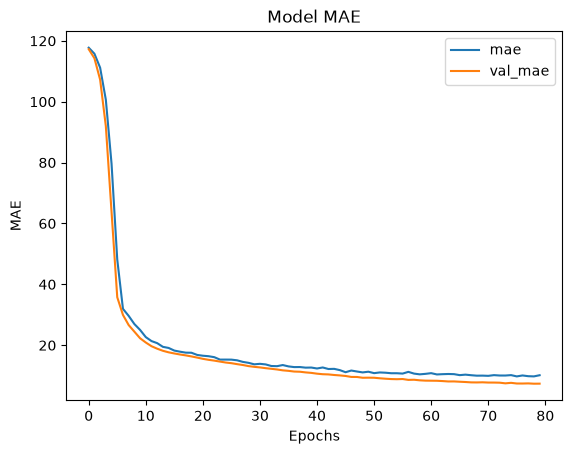

In [38]:
# 여기에 답안코드를 작성하고 실행하세요
plt.plot(history.history['mae'], label='mae')
plt.plot(history.history['val_mae'], label='val_mae')

# 기억하기
plt.title('Model MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

## 18. 마지막 비교

머신러닝 2개 모델과 딥러닝 모델의 **MAE를 비교**해서 가장 좋은 모델을 한 줄로 적으세요.

그리고 아래 질문에도 짧게 답하세요.

1. MAE는 클수록 좋은가, 작을수록 좋은가?
2. 회귀 문제의 마지막 출력층 unit이 1인 이유는?
3. 검증 데이터에 `fit_transform()`을 쓰면 왜 안 되는가?
4. `Dense(1, activation='linear')`에서 `linear`를 사용하는 이유는?


### 답안

1. 작을수록 좋다
2. 회귀에서는 컬럼 1개만 보니까...?
3. 검증데이터에 fit_transform을 하면 시험 상황에서 답지를 주는것과 같다 - 학습을 답지로 하는 격
4. 선형 회귀랑 관련있나...?